In [1]:
import datasets
from tqdm.auto import tqdm
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import AutoModelForSequenceClassification
from transformers import pipeline
import copy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from rich import print
import numpy as np
import random


/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [2]:
def chunk_string(text, chunk_size):
    return [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]

In [3]:
original_files = ['/home/takis/LLMUnlearning/data/shakespeare/antony-and-cleopatra_original.snt.aligned',
                  '/home/takis/LLMUnlearning/data/shakespeare/asyoulikeit_original.snt.aligned',
                  '/home/takis/LLMUnlearning/data/shakespeare/errors_original.snt.aligned',
                  '/home/takis/LLMUnlearning/data/shakespeare/hamlet_original.snt.aligned',
                  '/home/takis/LLMUnlearning/data/shakespeare/juliuscaesar_original.snt.aligned',
                  '/home/takis/LLMUnlearning/data/shakespeare/macbeth_original.snt.aligned']
modern_files = ['/home/takis/LLMUnlearning/data/shakespeare/antony-and-cleopatra_modern.snt.aligned',
                '/home/takis/LLMUnlearning/data/shakespeare/asyoulikeit_modern.snt.aligned',
                '/home/takis/LLMUnlearning/data/shakespeare/errors_modern.snt.aligned',
                '/home/takis/LLMUnlearning/data/shakespeare/hamlet_modern.snt.aligned',
                '/home/takis/LLMUnlearning/data/shakespeare/juliuscaesar_modern.snt.aligned',
                '/home/takis/LLMUnlearning/data/shakespeare/macbeth_modern.snt.aligned']


original_str = ''
for original_file in original_files:
    with open(original_file) as f:
        original_str = original_str + ' '.join(f.readlines())

modern_str = ''
for modern_file in modern_files:
    with open(modern_file) as f:
        modern_str = modern_str + ' '.join(f.readlines())   


prompts = []
original = []

original_prompts = random.sample(chunk_string(original_str, 500), 100)
original = original + len(original_prompts)*[1]
modern_prompts = random.sample(chunk_string(modern_str, 500), 100)
original = original + len(modern_prompts)*[0]

prompts = original_prompts + modern_prompts

len(prompts)

200

# Model

In [4]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '2'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

1

In [5]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct")
model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct").to(device)

Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.91it/s]


In [6]:
model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

In [7]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


for i, layer in enumerate(model.model.layers):
    layer.self_attn.register_forward_hook(get_activation(i))

In [8]:

hidden_states = []

for p in tqdm(prompts, total=len(prompts)):

    inputs = tokenizer(p, return_tensors="pt").input_ids
    outputs = model.forward(inputs.to(device))
        
    
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()

    hidden_states.append(copy.deepcopy(activations))
    activations = {}

100%|██████████| 200/200 [00:35<00:00,  5.61it/s]


In [9]:
target_layers = [i for i in range(len(model.model.layers))]

all_prompts_prototypes = [{target_layer: torch.mean(hidden_states[i][target_layer][0], dim=-2).to(device) 
                           for target_layer in target_layers} 
                           for i in range(len(hidden_states))]

In [10]:
prototypes = {l: {} for l in [0, 1]}
for target_layer in target_layers:
    for l in [0, 1]:

        cur_prototypes = []
        for i in range(len(all_prompts_prototypes)):
            if (original[i] != l):
                continue
            cur_prototypes.append(all_prompts_prototypes[i][target_layer])

        cur_prototypes = torch.stack(cur_prototypes, dim=0)

        prototypes[l][target_layer] = torch.mean(cur_prototypes, dim=0)

## Cosine similarity

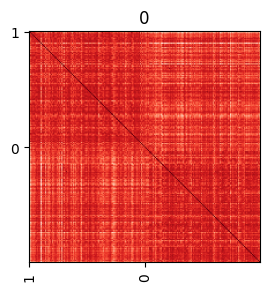

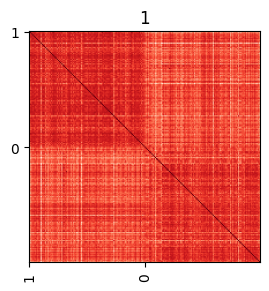

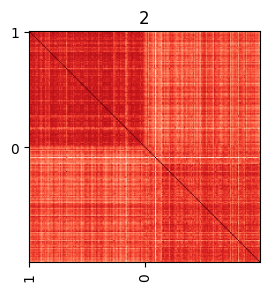

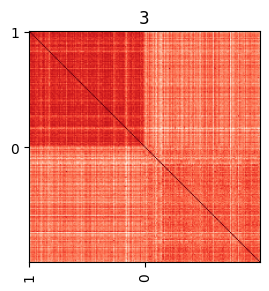

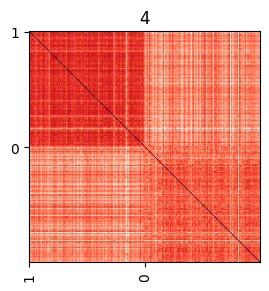

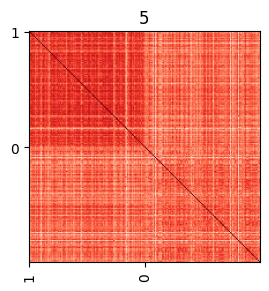

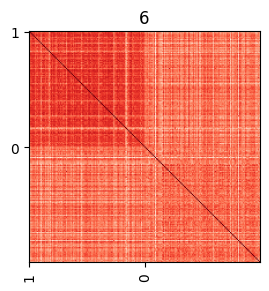

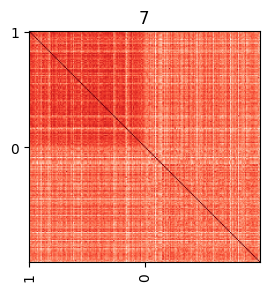

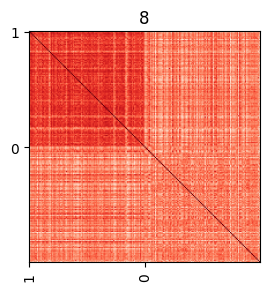

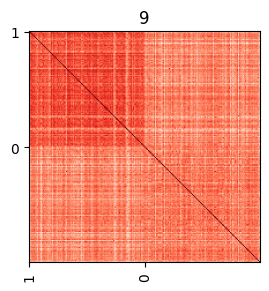

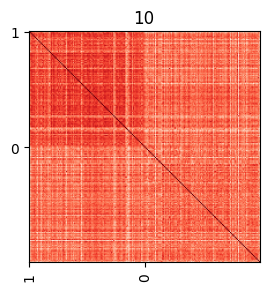

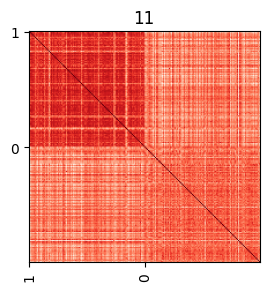

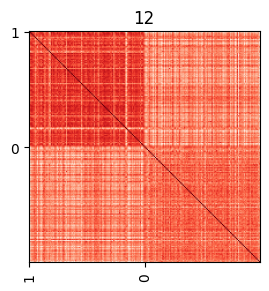

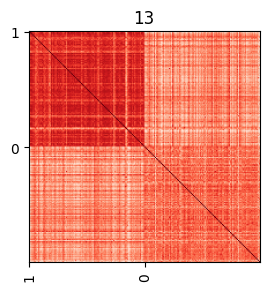

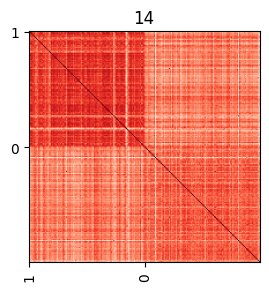

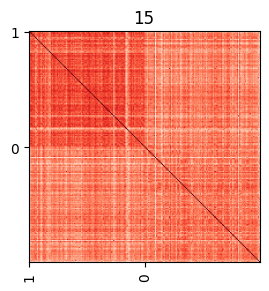

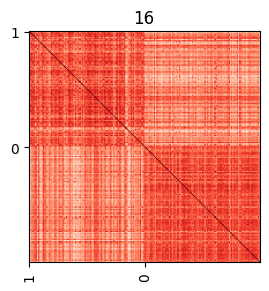

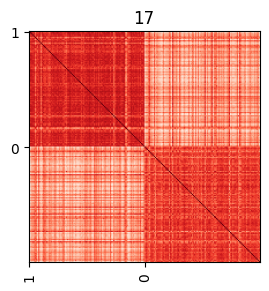

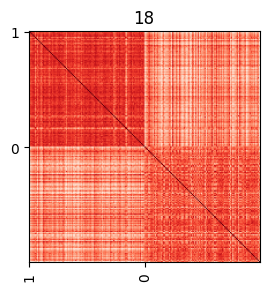

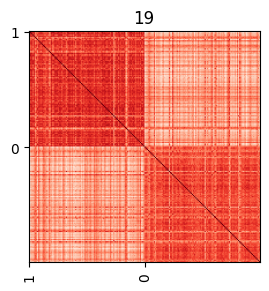

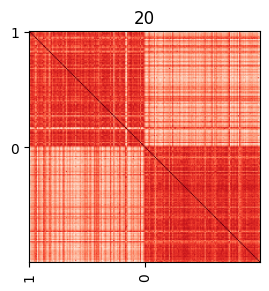

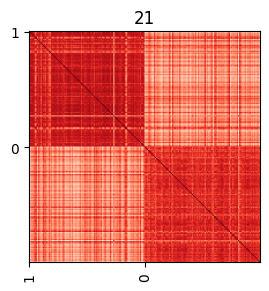

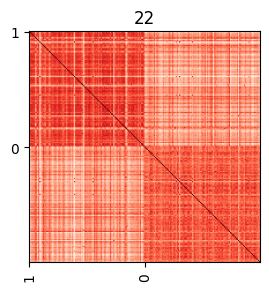

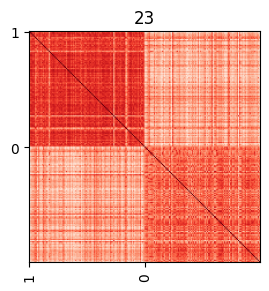

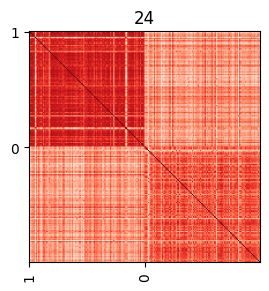

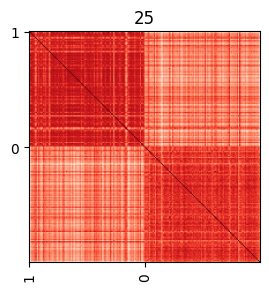

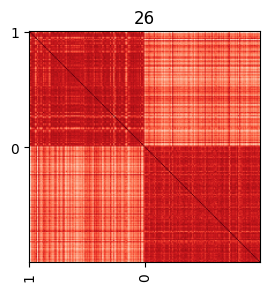

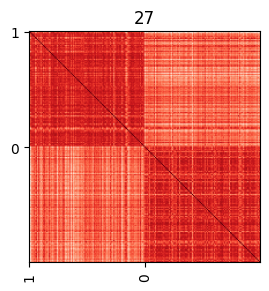

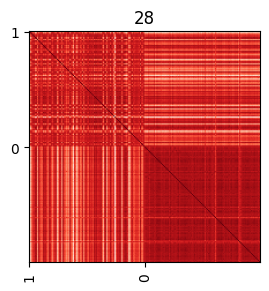

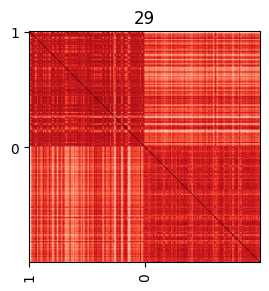

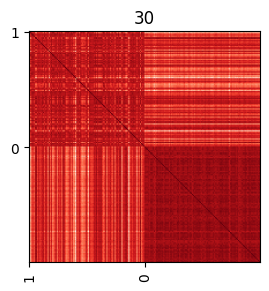

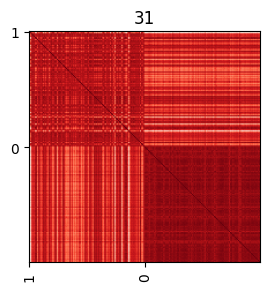

In [11]:
for target_layer in target_layers:

    # dis = np.zeros((len(prompts), len(prompts)))
    cs = np.zeros((len(prompts), len(prompts)))

    cs_func = nn.CosineSimilarity(dim=-1)

    for i in range(len(prompts)):
        for j in range(len(prompts)):
            # dis[i, j] = torch.linalg.norm(all_prompts_prototypes[i][target_layer] - all_prompts_prototypes[j][target_layer])
            cs[i, j] = cs_func(all_prompts_prototypes[i][target_layer], all_prompts_prototypes[j][target_layer])


    fig, ax = plt.subplots(figsize=(3, 3))
    plt.imshow(cs, cmap='Reds')
    plt.xticks([i for i in range(0, len(prompts), 100)], original[::100], rotation=90)
    plt.yticks([i for i in range(0, len(prompts), 100)], original[::100], rotation=0)
    plt.title(str(target_layer))
    plt.show()

# Behavior steering

In [30]:
for hook in hooks:
    hook.remove()

In [31]:
target_style = 1
strength = 1


def change_behavior(target_layer):
    def hook(model, input, output):
        output = (output[0] + strength*prototypes[target_style][target_layer].to(device), *output[1:])
        return output
    return hook


hooks = []
for i, layer in enumerate(model.model.layers):
    if (i == 17):
        print (i)
        hooks.append(layer.self_attn.register_forward_hook(change_behavior(i)))

# 13, 15
# 24 -> like a play

17

In [34]:
# prompt = """How are you today?"""


sentence = '''I hope you're having a great day so far. I'm feeling pretty good, thanks for asking. I just got back from a great 
run and I'm feeling energized and ready to tackle the day.

I was thinking about my goals for the next few weeks and I wanted to get your input. I've been wanting to start a 
new project, but I'm not sure where to start. Do you have any advice on how to get started on a new project?
'''

# sentence = '''Dear God, thank you!'''

prompt = 'Rephraze the following text: \'%s.\'' %(sentence)

# prompt = 'How are you today?'


In [35]:

target_style = 1

for strength in range(1, 40, 1):

    with torch.no_grad():
        inputs = tokenizer(prompt, return_tensors="pt").input_ids
        outputs = model.generate(inputs.to(device), max_new_tokens=100, do_sample=False, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id, use_cache=True).detach().cpu()
    output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]
    # output_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    print ('-------------------------------------------------')
    print (strength)
    print ('[white]%s[/white]' %(output_text))
        
    activations = {}

-------------------------------------------------

1

 
Rephrased text: 'I'm having a fantastic day so far, thanks for asking. I just got back from a great run and I'm 
feeling energized and 
ready to tackle the day.

I'd love to get your thoughts on my goals for the next few weeks. I'm considering starting a new project, but I'm 
not sure where to 
begin. Do you have any advice on how to get started on a new project?'

Rephrased text: 'I

-------------------------------------------------

2

...

38

 Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton

-------------------------------------------------

39

 Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton Singleton 
Singleton